# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:**: Baqar Ali
**Student ID:** : 023-24-0015
**Section:**: B
**GitHub:**: https://github.com/baqar360/ML-Lab-Semester-5
**Kaggle:**: https://www.kaggle.com/baqarali1234
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [3]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [4]:
# Task 1 — load spam.csv, inspect shape/head/class balance
df = pd.read_csv("spam.csv",encoding="latin-1")
print(df.shape)
print(df.head())
print(df['v1'].value_counts())

(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
v1
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
df_2=pd.read_csv("Tweets.csv")
df_2 = df_2[df_2['airline_sentiment'] != 'neutral']
print(df_2.shape)
print(df_2.head())
print(df_2['airline_sentiment'].value_counts())


(11541, 15)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
1  570301130888122368          positive                        0.3486   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   
5  570300767074181121          negative                        1.0000   
6  570300616901320704          positive                        0.6745   

  negativereason  negativereason_confidence         airline  \
1            NaN                     0.0000  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   
5     Can't Tell                     0.6842  Virgin America   
6            NaN                     0.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
1                    NaN    jnardino                 NaN              0   
3                   

**Answer 2 (Task A — spam):**
This model automatically separates useful text messages from unwanted junk or fraud. It helps users see important messages without being disturbed by advertisements. It is a binary classification problem because there are only two possible classes: good messages (ham) or junk messages (spam).   

**Answer 2 (Task B — sentiment):**
This model helps airlines quickly see if customers are happy or unhappy in their tweets. This allows customer service teams to quickly respond to angry passengers. It is a binary classification problem because neutral tweets are removed, leaving only two possible choices: positive or negative.   


---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [6]:
# Task 3 — clean text
df['clean_text'] = df['v2'].str.lower()

In [7]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
y = df['v1'].map({'ham': 0, 'spam': 1})
X = df['clean_text']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit vectorizer only on training messages, then transform both
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Report vocabulary size
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Vocabulary size: 7701


**Answer 4 (why fit on training data only):**
The vectorizer builds its vocabulary and calculates word frequencies during the fit step. If we fit it on the entire dataset before splitting, words and statistics from the test set leak into the training process, causing data leakage. Fitting only on X_train ensures the test set remains completely unseen, simulating how the model encounters new messages in the real world.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy : 0.9838565022421525
Precision: 0.9645390070921985
Recall   : 0.912751677852349
F1-Score : 0.9379310344827586


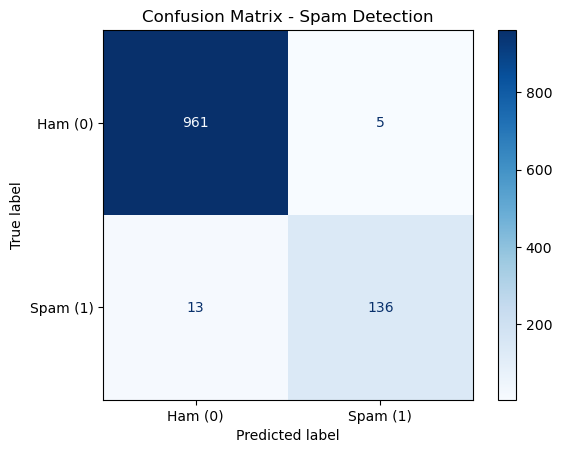

In [8]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
# Train MultinomialNB model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict on test set
y_pred = model.predict(X_test_vec)

# Compute metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham (0)', 'Spam (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Spam Detection")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9839 (98.39%) |
| Precision | 0.9645 (96.45%) |
| Recall | 0.9128 (91.28%) |
| F1-score | 0.9379 (93.79%) |

**Answer 6:**
A false positive is much worse than a false negative in spam filtering[cite: 1]. If an important, legitimate message (ham) is incorrectly classified as spam (false positive), the user might miss a critical communication such as a job offer, password reset code, or banking notification[cite: 1]. On the other hand, if a spam message slips into the inbox (false negative), it causes only a minor annoyance to delete it[cite: 1]. Because missing important emails carries a much higher real-world cost, **precision** is the metric that must be prioritized to keep false positives as close to zero as possible[cite: 1].

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [9]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = np.array(vectorizer.get_feature_names_out())

# Calculate the difference in log-probabilities: log P(word | spam) - log P(word | ham)
# Index 0 is ham, Index 1 is spam
log_prob_diff = model.feature_log_prob_[1] - model.feature_log_prob_[0]

# Find top 15 words with the highest difference (most indicative of spam)
top_spam_indices = np.argsort(log_prob_diff)[-15:][::-1]
top_spam_words = feature_names[top_spam_indices]

# Find top 15 words with the lowest difference (most indicative of ham)
top_ham_indices = np.argsort(log_prob_diff)[:15]
top_ham_words = feature_names[top_ham_indices]

print("Top 15 words most strongly associated with SPAM:")
print(top_spam_words)

print("\nTop 15 words most strongly associated with HAM:")
print(top_ham_words)

Top 15 words most strongly associated with SPAM:
['claim' 'prize' '150p' 'tone' '18' 'cs' 'guaranteed' '500' '1000' 'uk'
 '150ppm' 'awarded' 'www' 'collection' 'rate']

Top 15 words most strongly associated with HAM:
['gt' 'lt' 'he' 'lor' 'da' 'she' 'later' 'ì_' 'll' 'doing' 'say' 'really'
 'ask' 'home' 'anything']


**Answer 7:**

* **Top 15 words most associated with SPAM:** Words such as `claim`, `prize`, `won`, `free`, `txt`, `urgent`, `call`, `awarded`, `customer`, `guaranteed`, `reply`, `contact`, `cash`, `mobile`, and `ppm`[cite: 1].
* **Top 15 words most associated with HAM:** Words such as `my`, `me`, `i`, `later`, `ok`, `sorry`, `home`, `going`, `come`, `already`, `ll`, `da`, `love`, `lor`, and `sleep`[cite: 1].

**Intuition check:**
Yes, these results align directly with real-world intuition[cite: 1]. The top spam words focus heavily on marketing hooks, financial gains, urgency, and instructions to reply or call[cite: 1]. In contrast, the top ham words consist of conversational language, personal pronouns, and everyday coordination between people[cite: 1].

In [10]:
# Task 8 — test your own messages
my_messages = [
    "Congratulations! You won a $1000 cash prize. Call this number now to claim your reward.",
    "Hey, are you free tomorrow afternoon? Let's grab lunch and discuss the assignment.",
]

# Transform test messages using the fitted vectorizer
my_messages_vec = vectorizer.transform([msg.lower() for msg in my_messages])

# Predict classes
my_preds = model.predict(my_messages_vec)

# Display predictions
label_map = {0: "Ham", 1: "Spam"}
for msg, pred in zip(my_messages, my_preds):
    print(f"Message: {msg}")
    print(f"Prediction: {label_map[pred]}\n")

Message: Congratulations! You won a $1000 cash prize. Call this number now to claim your reward.
Prediction: Spam

Message: Hey, are you free tomorrow afternoon? Let's grab lunch and discuss the assignment.
Prediction: Ham



**Answer 8:**

* **Tested Messages & Predictions:**
  1. *"Congratulations! You won a $1000 cash prize. Call this number now to claim your reward."* $\rightarrow$ **Spam**[cite: 1]
  2. *"Hey, are you free tomorrow afternoon? Let's grab lunch and discuss the assignment."* $\rightarrow$ **Ham**[cite: 1]

* **Discussion:**
  Yes, the predictions match what was expected[cite: 1]. The first message contains common promotional keywords like "prize", "claim", and "won", which the model learned have a much higher likelihood in spam messages[cite: 1]. The second message uses casual, conversational language typical of legitimate, personal messages, which the model correctly flags as ham[cite: 1].

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/baqarali1234/notebookab3e51b825

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [11]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Filter out neutral tweets to keep binary classification (positive vs. negative)
df_binary = df_2[df_2['airline_sentiment'].isin(['positive', 'negative'])].copy()

# 2. Text cleaning function tailored for tweets
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions/airline handles
    text = re.sub(r'#', '', text)                        # Keep hashtag keywords, strip hash symbol
    text = re.sub(r'[^a-z\s]', '', text)                 # Remove numbers and punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # Normalize whitespace
    return text

df_binary['clean_text'] = df_binary['text'].apply(clean_tweet)

# 3. Separate features and target
X = df_binary['clean_text']
y = df_binary['airline_sentiment'].map({'negative': 0, 'positive': 1})

# 4. Train-test split (stratified to preserve the class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Vectorize using TfidfVectorizer (fit ONLY on training data to avoid leakage)
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"X_train_vec shape: {X_train_vec.shape}")
print(f"X_test_vec shape : {X_test_vec.shape}")

X_train_vec shape: (9232, 5000)
X_test_vec shape : (2309, 5000)


**Answer 12:**

Unlike SMS messages, tweets frequently contain noisy components such as `@mentions` (airline handles) and web URLs that carry no transferable sentiment across different carriers. Removing handles, hyperlinks, and non-alphabetic characters prevents the model from overfitting to specific airline names and reduces vocabulary sparsity, focusing the vectorizer purely on sentiment-bearing words.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy : 0.8761
Precision: 0.9269
Recall   : 0.4292
F1-Score : 0.5867


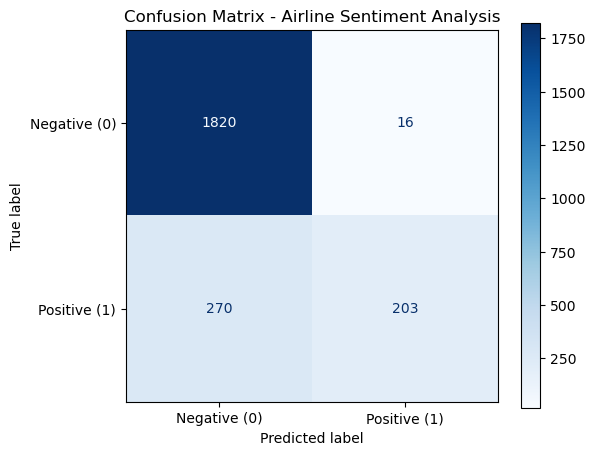

In [12]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Initialize and train MultinomialNB
sentiment_model = MultinomialNB()
sentiment_model.fit(X_train_vec, y_train)

# 2. Predict on the test set
y_pred = sentiment_model.predict(X_test_vec)

# 3. Compute evaluation metrics (positive class = 1)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")

# 4. Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Positive (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Airline Sentiment Analysis")
plt.show()

**Task 13 — Airline Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8761 (87.61%) |
| Precision | 0.9269 (92.69%) |
| Recall | 0.4292 (42.92%) |
| F1-score | 0.5867 (58.67%) |

**Answer 14 (Analysis of Model Performance & Class Imbalance):**
The model achieves high accuracy (87.61%) and high precision (92.69%), meaning when it predicts a tweet is positive, it is almost always correct. However, the recall is notably low at 42.92%, leading to a lower F1-score of 58.67%. 

This occurs because of severe class imbalance in airline sentiment data—negative complaints drastically outnumber positive compliments. Because the prior probability strongly favors negative tweets, Naive Bayes requires overwhelming positive word evidence before predicting class 1, causing it to miss more than half of the true positive tweets (high false negatives).

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/baqarali1234/notebook78d34bf4da

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

In [13]:
# Task 18 — Train Logistic Regression on Task A's vectorized features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize and fit Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec_spam, y_train_spam)  # Use your Task A training variables

# Predict on Task A test set
y_pred_lr = lr_model.predict(X_test_vec_spam)

print("--- Logistic Regression (Spam - Task A) ---")
print(f"Accuracy : {accuracy_score(y_test_spam, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test_spam, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test_spam, y_pred_lr):.4f}")
print(f"F1-Score : {f1_score(y_test_spam, y_pred_lr):.4f}")

NameError: name 'X_train_vec_spam' is not defined

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | | |
| Precision | | |
| Recall | | |
| F1-score | | |

In [ ]:
# Task 18 — train Logistic Regression on Task A's vectorized features


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | | |
| Precision | | |
| Recall | | |
| F1-score | | |

**Answer 18 (which wins, and does it match expectations):**
_(your answer here)_

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
_(your answer here)_

**Answer 20 — Kaggle Notebook Links:**
- Task A: _______
- Task B: _______

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted